#  INSTALLING ALL LIBRARIES :

In [1]:
!pip install google-generativeai umap-learn scikit-learn matplotlib --quiet
!pip install google-generativeai xgboost --quiet
!pip install chromadb -q
!pip install adjustText

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

# IMPORTING ALL LIBRARIES

In [2]:
import google.generativeai as genai
import umap
import matplotlib.pyplot as plt
from adjustText import adjust_text
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import re
import xgboost as xgb
import chromadb

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


# Configuring Gemini

In [4]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

In [5]:
genai.configure(api_key=GOOGLE_API_KEY)

genai.configure: Connects your code to Google's servers using your unique password (API Key).

# Visualizing Twitter Data

In [6]:
import time

def get_gemini_embeddings_ld(texts, model="models/gemini-embedding-001"):
    embeddings = []
    print(f"Starting to process {len(texts)} words...")

    for i, text in enumerate(texts):
        try:
            # Wait 1 second to respect the free tier limit
            time.sleep(1)

            result = genai.embed_content(
                model=model,
                content=text,
                task_type="retrieval_document"
            )
            embeddings.append(result['embedding'])

            if (i + 1) % 5 == 0:
                print(f"Processed {i + 1}/{len(texts)} words...")

        except Exception as e:
            print(f"⚠️ Error on word '{text}': {e}")
            print("Waiting 30 seconds for rate limit...")
            time.sleep(30)
            # Retry once
            try:
                result = genai.embed_content(
                    model=model,
                    content=text,
                    task_type="retrieval_document"
                )
                embeddings.append(result['embedding'])
                print("✅ Retry successful!")
            except:
                print(f"❌ Failed again. Skipping.")
                embeddings.append([0] * 768)

    return np.array(embeddings)

def get_gemini_embeddings_Id(texts, model): Define a reusable function.

genai.embed_content(...): This is the core magic. It sends your text to Gemini (models/text-embedding-004) and asks for its "embedding".


task_type="retrieval_document": Tells Gemini "I plan to use this text to be found in a search later".

return np.array(embeddings): Returns the list of numbers in a format efficient for math (NumPy array).



> Why a new function? APIs often crash or reject requests if you send 10,000 words at once. This function breaks the work into "batches" of 50 to be safe.



In [8]:
# Load Twitter Dataset
sc_df = pd.read_csv("/content/Tweets.csv")

# Filter for text and sentiment columns
sc_df = sc_df[['sentiment', 'text']]


# Display first few rows
print(sc_df.head())
print("Shape:", sc_df.shape)

  sentiment                                               text
0   neutral                I`d have responded, if I were going
1  negative      Sooo SAD I will miss you here in San Diego!!!
2  negative                          my boss is bullying me...
3  negative                     what interview! leave me alone
4  negative   Sons of ****, why couldn`t they put them on t...
Shape: (27481, 2)




> sc_df = pd.read_csv("/content/Tweets.csv")
*   What it does: It reads a CSV file named Tweets.csv (located inside a folder named content) and loads it into a Pandas DataFrame called sc_df.


> sc_df = sc_df[['text', 'sentiment']]
*   What it does: It keeps only two specific columns: text (the tweet itself) and sentiment (whether it's positive/negative). It throws away all other columns.




In [9]:
# Data Preprocessing
def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text)    # Remove Mentions (@user)
    text = re.sub(r'#\w+', '', text)    # Remove Hashtags
    text = re.sub(r'[^\w\s]', '', text) # Remove Punctuation
    return text.lower().strip()

print("Cleaning text...")




Cleaning text...


Twitter data is messy. This function uses "Regular Expressions" (regex) to scrub the text clean so the AI doesn't get confused.

In [10]:
sc_df['text'] = sc_df['text'].apply(clean_text)
sc_df = sc_df.head(350) # USING FIRST 500 FOR DEMO SPEED - REMOVE THIS LINE FOR FULL DATA


> sc_df['text'] = sc_df['text'].apply(clean_text)


*   This runs the cleaning function on every single tweet in your list.








> sc_df = sc_df.head(1000)



*   Important! This line throws away everything except the first 1,000 tweets to make the code run faster for the demo.




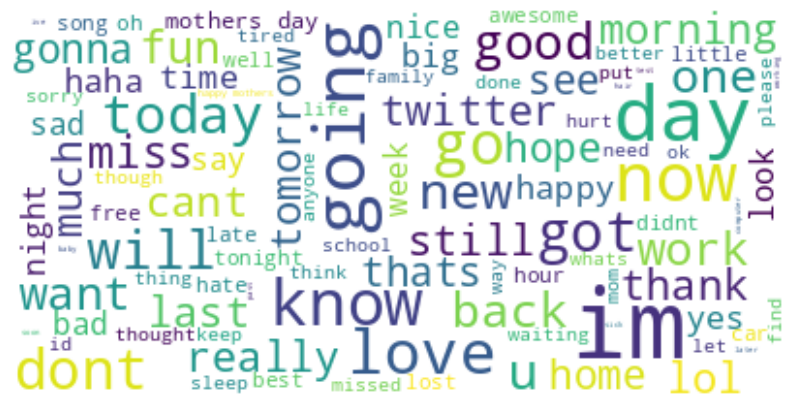

In [11]:
from wordcloud import WordCloud
text_cloud = " ".join(review for review in sc_df.text)
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text_cloud)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()



> text_cloud = " ".join(review for review in sc_df.text)



*   It takes all 1,000 cleaned tweets and glues them together into one giant string of text.
*   List item






> wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text_cloud)



*   This library counts how often every word appears.



### The Result: It creates an image where larger words = more frequent words.

In [12]:
sc_df.sentiment.unique()

array(['neutral', 'negative', 'positive'], dtype=object)



> sc_df.sentiment.unique()


*   sc_df.sentiment: Points to the specific column named "sentiment" in your table.

*   .unique(): Scans that whole column and returns a list of unique values, removing any duplicates.





In [13]:
# 1. Remove any empty strings resulting from cleaning
sc_df = sc_df[sc_df['text'].str.strip().astype(bool)]




*   What it does: Removes "Empty" tweets.
*   Why: Sometimes our cleaning process (fixing emojis, deleting links) leaves a tweet completely empty. For example, a tweet that was just a link "http://google.com" becomes "" after cleaning. We need to delete these so the AI doesn't get confused



In [14]:
# 2. Generate embeddings from tweets
X = get_gemini_embeddings_ld(sc_df["text"].tolist())

Starting to process 349 words...
Processed 5/349 words...
Processed 10/349 words...
Processed 15/349 words...
Processed 20/349 words...
Processed 25/349 words...
Processed 30/349 words...
Processed 35/349 words...
Processed 40/349 words...
Processed 45/349 words...
Processed 50/349 words...
Processed 55/349 words...
Processed 60/349 words...
Processed 65/349 words...
Processed 70/349 words...
Processed 75/349 words...
Processed 80/349 words...
Processed 85/349 words...
Processed 90/349 words...
Processed 95/349 words...
Processed 100/349 words...
Processed 105/349 words...
Processed 110/349 words...
Processed 115/349 words...
Processed 120/349 words...
Processed 125/349 words...
Processed 130/349 words...
Processed 135/349 words...
Processed 140/349 words...
Processed 145/349 words...
Processed 150/349 words...
Processed 155/349 words...
Processed 160/349 words...
Processed 165/349 words...
Processed 170/349 words...
Processed 175/349 words...
Processed 180/349 words...
Processed 185/3

> This is the main step



*   What it does: It takes our list of tweet texts and runs them through the function we wrote earlier.
*   Result: X becomes a giant list of vectors (numbers). X is our Input Data.




In [15]:
# 3. Map 3 classes: negative, neutral, positive
label_map = {"negative": 0, "neutral": 1, "positive": 2}
y = sc_df["sentiment"].map(label_map).values



> label_map = {"negative": 0, "neutral": 1, "positive": 2}



*   What it does: Computers don't understand words like "negative". They only understand numbers.


> We create a rule:
1.   negative -> 0
2.  neutral -> 1
3.   positive -> 2







> y = sc_df["sentiment"].map(label_map).values



*   What it does: Applies that rule to the "sentiment" column.
*   Result: y becomes a list of numbers like [0, 2, 1, 0...] instead of ["negative", "positive"...]. y is our Target Answer.



In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)




> test_size=0.2


*   Meaning: "Use 20% of the data for the Final Exam (Testing), and keep 80% for Studying (Training)."

*   Why: You never test the AI on the same questions it studied, or it might just memorize the answers. You need fresh questions to see if it actually learned.






> stratify=y

*   Meaning: "Make sure the Exam has the same difficulty as the Material."
*   Why: If 10% of tweets are Negative, stratify ensures that exactly 10% of the Training set is Negative, and 10% of the Testing set is Negative. This prevents the AI from getting a "biased".





> random_state=42

*   Meaning: "Shuffle the deck the exact same way every time."

*   Why: If you run this code today and tomorrow, you want the exact same split so your results are consistent and reproducible.





In [17]:
# Train XGBoost classifier (Multi-class)
clf = xgb.XGBClassifier(objective="multi:softmax", num_class=3, eval_metric="mlogloss")
clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)



> clf = xgb.XGBClassifier(...)


*   What it does:
It creates a new, empty brain (the clf or "Classifier"). It hasn't learned anything yet.

> The Settings:



1.   objective="multi:softmax": This is crucial! It tells the model, "You are choosing between multiple options (Negative, Neutral, Positive), not just Yes/No."

2.   num_class=3: Explicitly tells the model there are 3 possible answers.
3.   eval_metric="mlogloss": This is how the model grades itself while learning. "Log Loss" penalizes wrong answers confidently.








In [18]:
# Evaluate model
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))



              precision    recall  f1-score   support

    Negative       0.71      0.75      0.73        20
     Neutral       0.56      0.67      0.61        30
    Positive       0.69      0.45      0.55        20

    accuracy                           0.63        70
   macro avg       0.65      0.62      0.63        70
weighted avg       0.64      0.63      0.62        70





> y_pred = clf.predict(X_test)


*   What it does: The AI takes the "Exam Questions" (X_test) and writes down its own answers (y_pred). It doesn't know the real answers yet.






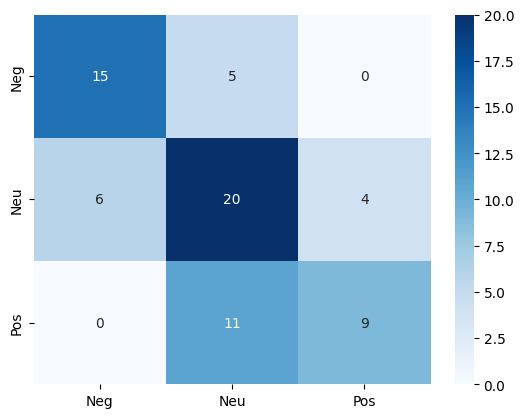

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Neg", "Neu", "Pos"], yticklabels=["Neg", "Neu", "Pos"])
plt.show()



> cm and sns.heatmap



*   What it does: It draws a colorful grid.


*   Why: A simple score like "80% accuracy" hides details. This grid shows you where it made mistakes.



In [20]:
def get_gemini_embeddings(texts):
    # ... checks if input is a single string and puts it in a list ...
    embeddings = []
    for text in texts:
        result = genai.embed_content(
            model="models/gemini-embedding-001",  #HERE I CHANGE THE MODEL BECAUSE THE ONE I AM USING BEFORE GIVES AN ERROR("models/text-embedding-004")
            content=text,
            task_type="retrieval_document"
        )
        embeddings.append(result['embedding'])
    return np.array(embeddings)

In [21]:
# Predict sentiment for new review
def predict_sentiment(text):
    emb = get_gemini_embeddings([text])
    pred = clf.predict(emb)[0]
    labels = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return labels[pred]




> 1. emb = get_gemini_embeddings([text])


*   What it does: It takes a new English sentence (like "I loved the flight") and sends it to Google to get its numbers (the embedding vector).











> 2. pred = clf.predict(emb)[0]

*   What it does: It gives those numbers to your trained AI brain (clf).
*   The AI thinks: "I've seen these kinds of numbers before... this looks like a Type 2(Positive)."

*   Result: pred becomes 2.












> 3. labels = {0: "Negative", 1: "Neutral", 2: "Positive"}

*   What it does: This is the dictionary to translate "Computer Speak" back to "Human Speak."










> 4. return labels[pred]

*   Final Output: The function returns the word "Positive" (because labels[2] is "Positive").





In [22]:
# Example Prediction 1
sample = "Democarcy is a fiction"
print("Tweet:", sample)
print("Prediction:", predict_sentiment(sample))

Tweet: Democarcy is a fiction
Prediction: Negative


In [23]:
# Example Prediction 2
sample = "I loved it"
print("Tweet:", sample)
print("Prediction:", predict_sentiment(sample))

Tweet: I loved it
Prediction: Positive


In [24]:
# Example Prediction 3
sample = "The truth ultimately is one, because reality is one"
print("Tweet:", sample)
print("Prediction:", predict_sentiment(sample))

Tweet: The truth ultimately is one, because reality is one
Prediction: Neutral


In [25]:
# Example Prediction 4
sample = "Pakistan cricket team is performing bad"
print("Tweet:", sample)
print("Prediction:", predict_sentiment(sample))

Tweet: Pakistan cricket team is performing bad
Prediction: Negative


In [26]:
# Example Prediction 5
sample = "We have nothing to loose"
print("Tweet:", sample)
print("Prediction:", predict_sentiment(sample))

Tweet: We have nothing to loose
Prediction: Neutral
